# Exploratory Data Analysis - Online Retail\n
\n
Tujuan notebook ini:\n
- Audit kualitas data dan anomali (mis. quantity negatif).\n
- EDA menyeluruh untuk memahami pola demand.\n
- Menyusun pipeline cleaning untuk kebutuhan demand forecasting (per hari per produk).\n
\n
Catatan: notebook hanya menampilkan hasil data bersih (preview/statistik), tidak menyimpan ke disk.

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

In [149]:
data_path = "../data/raw/online_retail.csv"
df_raw = pd.read_csv(data_path)
df_raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [150]:
df_raw.shape

(1067371, 8)

## Audit Kualitas Data

In [151]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [152]:
missing_summary = df_raw.isna().sum().sort_values(ascending=False)
missing_summary

Customer ID    243007
Description      4382
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

In [153]:
duplicate_rows = df_raw.duplicated().sum()
duplicate_rows

np.int64(34335)

### Deteksi Anomali dan Nilai Tidak Masuk Akal\n
Contoh anomali: quantity negatif, price nol/negatif, InvoiceDate invalid, atau StockCode kosong.

In [154]:
anomaly_summary = pd.DataFrame([{
    "quantity_le_0": (df_raw["Quantity"] <= 0).sum(),
    "price_le_0": (df_raw["Price"] <= 0).sum(),
    "missing_invoice_date": df_raw["InvoiceDate"].isna().sum(),
    "missing_stock_code": df_raw["StockCode"].isna().sum(),
    "missing_invoice": df_raw["Invoice"].isna().sum(),
}])
anomaly_summary

,quantity_le_0,price_le_0,missing_invoice_date,missing_stock_code,missing_invoice
0,22950,6207,0,0,0


## Pipeline Cleaning (Target: Demand per Hari per Produk)

In [155]:
def clean_online_retail(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df = df.rename(columns={
        "Invoice": "invoice",
        "StockCode": "stock_code",
        "Description": "description",
        "Quantity": "quantity",
        "InvoiceDate": "invoice_date",
        "Price": "price",
        "Customer ID": "customer_id",
        "Country": "country",
    })

    df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    df["price"] = pd.to_numeric(df["price"], errors="coerce")

    df["stock_code"] = df["stock_code"].astype(str).str.strip().str.upper()
    df["invoice"] = df["invoice"].astype(str).str.strip()

    df = df.drop_duplicates()

    df = df[df["invoice_date"].notna()]
    df = df[df["stock_code"].notna() & (df["stock_code"] != "")]
    df = df[df["invoice"].notna() & (df["invoice"] != "")]

    df = df[~df["invoice"].str.startswith("C", na=False)]

    non_product_codes = {
        "POST",
        "DOT",
        "C2",
        "M",
        "D",
        "ADJUST",
        "ADJUST2",
        "BANK CHARGES",
        "AMAZONFEE",
        "B",
        "S",
        "PADS",
        "TEST001",
        "TEST002",
        "GIFT_0001_10",
        "GIFT_0001_20",
        "GIFT_0001_30",
        "GIFT_0001_40",
        "GIFT_0001_50",
        "GIFT_0001_70",
        "GIFT_0001_80",
    }
    df = df[~df["stock_code"].isin(non_product_codes)]

    df = df[(df["quantity"] > 0) & (df["price"] > 0)]

    df["revenue"] = df["quantity"] * df["price"]

    return df

df_clean = clean_online_retail(df_raw)
df_clean.shape

(1003340, 9)

In [156]:
df_clean.head()

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [157]:
# tampilkan baris dengan stock_code non-angka dari df_clean
mask_non_numeric = ~df_clean["stock_code"].astype(str).str.match(r"^\d+$")
non_numeric_stockcodes = df_clean[mask_non_numeric]
non_numeric_stockcodes

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
12,489436,48173C,DOOR MAT BLACK FLOCK,10,2009-12-01 09:06:00,5.95,13078.0,United Kingdom,59.50
23,489436,35004B,SET OF 3 BLACK FLYING DUCKS,12,2009-12-01 09:06:00,4.65,13078.0,United Kingdom,55.80
28,489436,84596F,SMALL MARSHMALLOWS PINK BOWL,8,2009-12-01 09:06:00,1.25,13078.0,United Kingdom,10.00
...,...,...,...,...,...,...,...,...,...
1067239,581578,84997C,CHILDRENS CUTLERY POLKADOT BLUE,8,2011-12-09 12:16:00,4.15,12713.0,Germany,33.20
1067270,581579,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,2011-12-09 12:19:00,1.79,17581.0,United Kingdom,17.90
1067302,581580,84993A,75 GREEN PETIT FOUR CASES,2,2011-12-09 12:20:00,0.42,12748.0,United Kingdom,0.84
1067308,581580,85049A,TRADITIONAL CHRISTMAS RIBBONS,1,2011-12-09 12:20:00,1.25,12748.0,United Kingdom,1.25


In [158]:
mask_invoice_c = df_clean["invoice"].astype(str).str.startswith("C", na=False)
invoice_c_rows = df_clean.loc[mask_invoice_c].copy()

invoice_c_rows.head(50)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue


In [159]:
pattern = r'^\d+[A-Za-z]?$'
mask_invalid = ~df_clean['stock_code'].astype(str).str.match(pattern)

invalid = df_clean.loc[mask_invalid, ['stock_code', 'description']].copy()
invalid_summary = (
    invalid.groupby('stock_code', as_index=False)
    .agg(rows=('stock_code', 'size'), sample_description=('description', 'first'))
    .sort_values('rows', ascending=False)
)

print(f"Total baris tidak cocok: {len(invalid)}")
print(f"Unique stock_code tidak cocok: {invalid_summary.shape[0]}")
invalid_summary.head(200)

Total baris tidak cocok: 1335
Unique stock_code tidak cocok: 20


,stock_code,rows,sample_description
0,15056BL,956,EDWARDIAN PARASOL BLACK
2,79323LP,170,LIGHT PINK CHERRY LIGHTS
1,79323GR,83,GREEN CHERRY LIGHTS
8,DCGS0058,30,MISO PRETTY GUM
18,DCGSSGIRL,23,GIRLS PARTY BAG
17,DCGSSBOY,21,BOYS PARTY BAG
16,DCGS0076,14,SUNJAR LED NIGHT NIGHT LIGHT
3,DCGS0003,13,BOXED GLASS ASHTRAY
12,DCGS0069,5,OOH LA LA DOGS COLLAR
4,DCGS0004,4,HAYNES CAMPER SHOULDER BAG


In [160]:
# Filter df_clean untuk stock_code yang tidak cocok dengan pola ^\d+[A-Za-z]?$
pattern = r'^\d+[A-Za-z]?$'
mask_invalid_pattern = ~df_clean['stock_code'].astype(str).str.match(pattern)

invalid_stockcodes = df_clean[mask_invalid_pattern][['stock_code', 'description', 'quantity', 'revenue']].copy()
invalid_summary = (
    invalid_stockcodes.groupby('stock_code', as_index=False)
    .agg(
        rows=('stock_code', 'size'),
        sample_description=('description', 'first'),
        total_qty=('quantity', 'sum'),
        total_revenue=('revenue', 'sum')
    )
    .sort_values('rows', ascending=False)
)

print(f"Total baris dengan stock_code tidak cocok: {len(invalid_stockcodes)}")
print(f"Unique stock_code tidak cocok: {invalid_summary.shape[0]}\n")
invalid_summary

Total baris dengan stock_code tidak cocok: 1335
Unique stock_code tidak cocok: 20



,stock_code,rows,sample_description,total_qty,total_revenue
0,15056BL,956,EDWARDIAN PARASOL BLACK,9620,48723.77
2,79323LP,170,LIGHT PINK CHERRY LIGHTS,1433,8481.19
1,79323GR,83,GREEN CHERRY LIGHTS,532,3209.36
8,DCGS0058,30,MISO PRETTY GUM,42,34.82
18,DCGSSGIRL,23,GIRLS PARTY BAG,92,295.63
17,DCGSSBOY,21,BOYS PARTY BAG,77,251.35
16,DCGS0076,14,SUNJAR LED NIGHT NIGHT LIGHT,17,275.96
3,DCGS0003,13,BOXED GLASS ASHTRAY,13,32.59
12,DCGS0069,5,OOH LA LA DOGS COLLAR,5,80.31
4,DCGS0004,4,HAYNES CAMPER SHOULDER BAG,4,67.94


In [161]:
df_clean.loc[df_clean["stock_code"] == "PADS"]

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue


## EDA - Distribusi dan Ringkasan

In [162]:
df_clean[["quantity", "price", "revenue"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

,quantity,price,revenue
count,1.003340e+06,1.003340e+06,1.003340e+06
mean,1.115080e+01,3.340145e+00,1.957847e+01
std,1.287390e+02,4.754894e+00,1.999834e+02
min,1.000000e+00,3.000000e-02,6.000000e-02
50%,4.000000e+00,2.100000e+00,1.008000e+01
90%,2.400000e+01,7.620000e+00,3.285000e+01
95%,3.200000e+01,9.950000e+00,5.950000e+01
99%,1.080000e+02,1.695000e+01,1.790000e+02
max,8.099500e+04,1.157150e+03,1.684696e+05


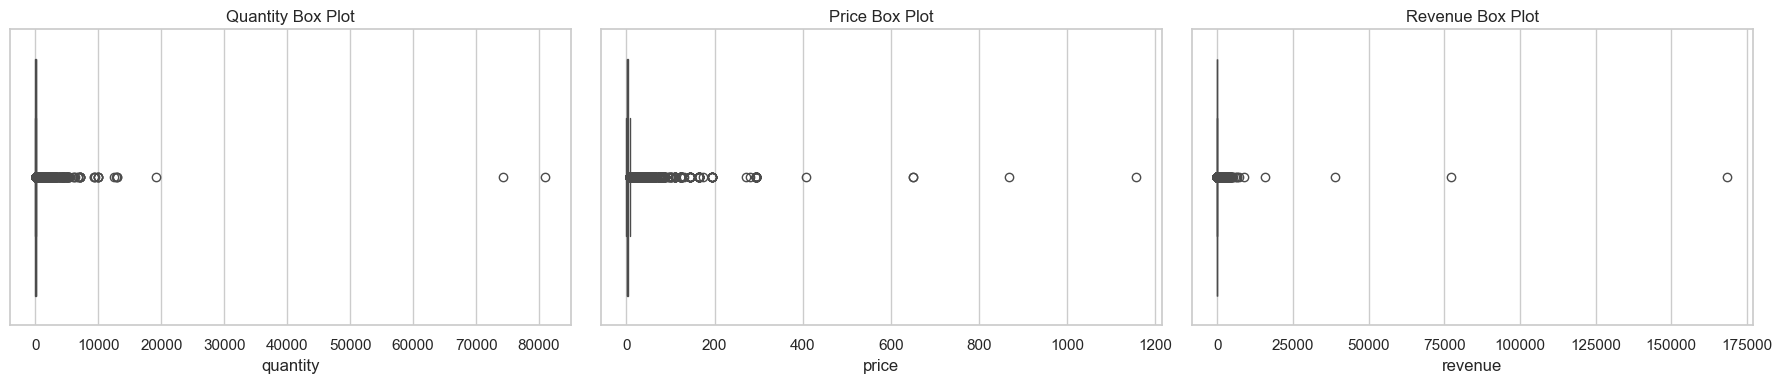

In [163]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(x=df_clean["quantity"], ax=axes[0])
axes[0].set_title("Quantity Box Plot")

sns.boxplot(x=df_clean["price"], ax=axes[1])
axes[1].set_title("Price Box Plot")

sns.boxplot(x=df_clean["revenue"], ax=axes[2])
axes[2].set_title("Revenue Box Plot")

plt.tight_layout()

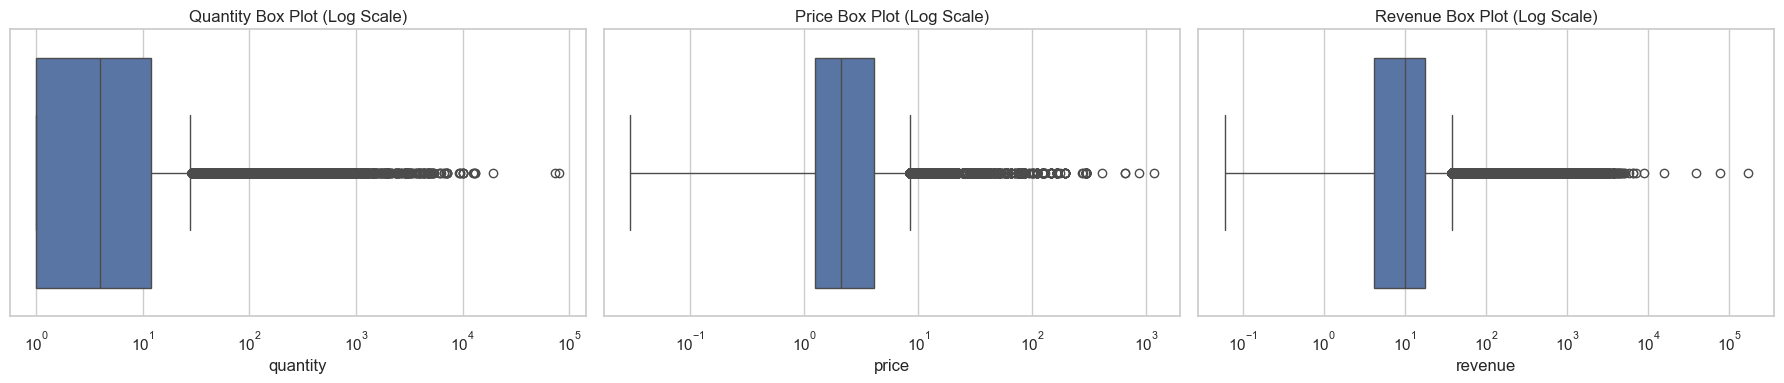

In [164]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(x=df_clean["quantity"], ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Quantity Box Plot (Log Scale)")

sns.boxplot(x=df_clean["price"], ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Price Box Plot (Log Scale)")

sns.boxplot(x=df_clean["revenue"], ax=axes[2])
axes[2].set_xscale("log")
axes[2].set_title("Revenue Box Plot (Log Scale)")

plt.tight_layout()

## Top Produk dan Negara

In [165]:
top_products = (
    df_clean.groupby("stock_code", as_index=False)
    .agg(demand_qty=("quantity", "sum"), revenue=("revenue", "sum"))
    .sort_values("demand_qty", ascending=False)
    .head(10)
)
top_products

,stock_code,demand_qty,revenue
3480,84077,106139,24445.61
4130,85099B,97176,182680.98
609,21212,94884,51825.15
4152,85123A,94719,261168.73
1427,22197,88499,79520.20
2792,23843,80995,168469.60
3890,84879,80082,129324.49
2347,23166,78033,81700.92
110,17003,70369,14766.42
1240,21977,56061,28081.73


In [166]:
top_countries = (
    df_clean.groupby("country", as_index=False)
    .agg(demand_qty=("quantity", "sum"), revenue=("revenue", "sum"))
    .sort_values("demand_qty", ascending=False)
    .head(10)
)
top_countries

,country,demand_qty,revenue
40,United Kingdom,9176174,16801019.37
26,Netherlands,383625,549773.41
11,EIRE,336088,623414.16
14,France,270582,311090.29
10,Denmark,237406,67422.69
15,Germany,223088,383289.00
0,Australia,103753,167800.01
35,Sweden,88537,86319.14
36,Switzerland,52612,94024.59
34,Spain,49996,97766.75


## Tren Waktu

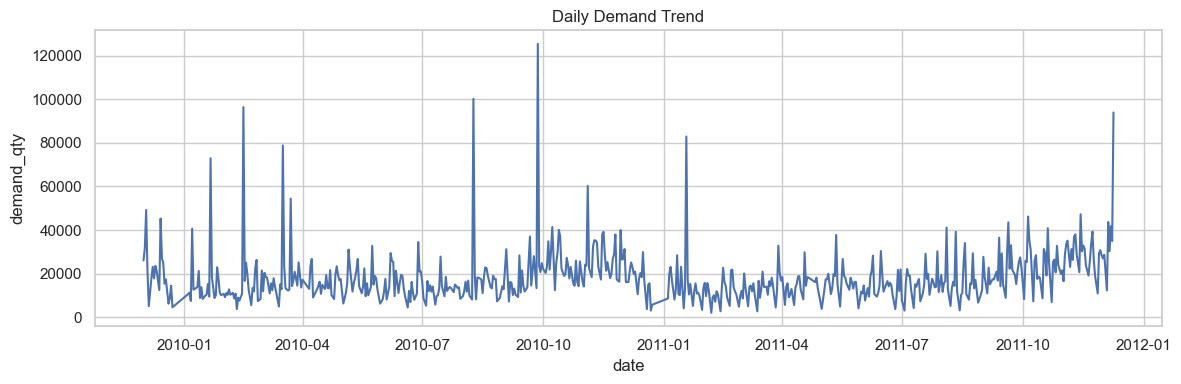

In [167]:
df_clean["date"] = df_clean["invoice_date"].dt.date
daily_trend = (
    df_clean.groupby("date", as_index=False)
    .agg(demand_qty=("quantity", "sum"), revenue=("revenue", "sum"))
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=daily_trend, x="date", y="demand_qty")
plt.title("Daily Demand Trend")
plt.tight_layout()

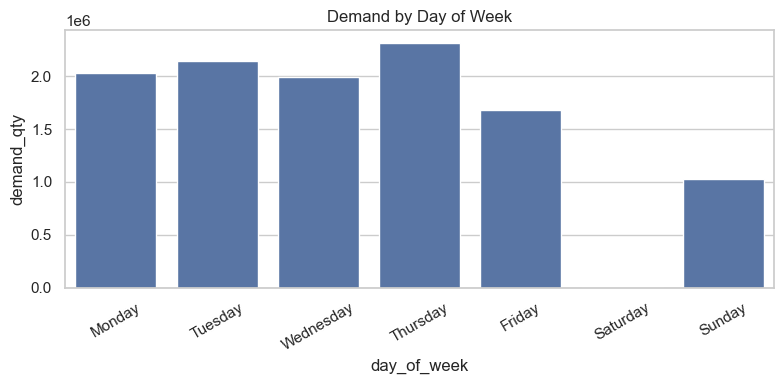

In [168]:
df_clean["day_of_week"] = df_clean["invoice_date"].dt.day_name()
dow = (
    df_clean.groupby("day_of_week", as_index=False)
    .agg(demand_qty=("quantity", "sum"))
)
dow["day_of_week"] = pd.Categorical(dow["day_of_week"], categories=[
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
], ordered=True)
dow = dow.sort_values("day_of_week")

plt.figure(figsize=(8, 4))
sns.barplot(data=dow, x="day_of_week", y="demand_qty")
plt.title("Demand by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()

## Dataset Harian per Produk (Siap untuk Forecasting)

In [169]:
def build_daily_product_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["date"] = df["invoice_date"].dt.normalize()

    daily = (
        df.groupby(["stock_code", "date"], as_index=False)
        .agg(
            demand_qty=("quantity", "sum"),
            revenue=("revenue", "sum"),
            num_invoices=("invoice", "nunique"),
        )
    )

    stock_codes = daily["stock_code"].unique()
    full_dates = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
    full_index = pd.MultiIndex.from_product([stock_codes, full_dates], names=["stock_code", "date"])

    daily = (
        daily.set_index(["stock_code", "date"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    return daily

daily_product = build_daily_product_dataset(df_clean)
daily_product.head()

,stock_code,date,demand_qty,revenue,num_invoices
0,10002,2009-12-01,12,10.20,1
1,10002,2009-12-02,0,0.00,0
2,10002,2009-12-03,6,5.10,3
3,10002,2009-12-04,73,62.05,4
4,10002,2009-12-05,0,0.00,0


## Dataset untuk Model Time Series dan Tabular

In [171]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["day_of_week"] = df["date"].dt.dayofweek
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["month"] = df["date"].dt.month
    df["quarter"] = df["date"].dt.quarter
    df["day_of_month"] = df["date"].dt.day
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["date"].dt.is_month_end.astype(int)
    return df

def add_lag_rolling_features(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values([group_col, "date"])

    for lag in [1, 7, 14, 28]:
        df[f"lag_{lag}"] = df.groupby(group_col)["demand_qty"].shift(lag)

    for window in [7, 14, 28]:
        df[f"roll_mean_{window}"] = (
            df.groupby(group_col)["demand_qty"]
            .shift(1)
            .rolling(window=window, min_periods=1)
            .mean()
        )

    for window in [7, 28]:
        df[f"roll_std_{window}"] = (
            df.groupby(group_col)["demand_qty"]
            .shift(1)
            .rolling(window=window, min_periods=1)
            .std()
        )

    df["diff_1"] = df.groupby(group_col)["demand_qty"].diff(1)
    df["diff_7"] = df.groupby(group_col)["demand_qty"].diff(7)

    return df

def add_product_features(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    df = df.copy()
    product_demand = df.groupby(group_col)["demand_qty"].sum().rename("product_popularity")
    product_revenue = df.groupby(group_col)["revenue"].sum().rename("product_revenue_total")
    total_revenue = df["revenue"].sum()

    df = df.merge(product_demand, on=group_col, how="left")
    df = df.merge(product_revenue, on=group_col, how="left")
    df["product_revenue_share"] = df["product_revenue_total"] / total_revenue

    first_sale = df.groupby(group_col)["date"].min().rename("first_sale_date")
    df = df.merge(first_sale, on=group_col, how="left")
    df["product_lifecycle_age"] = (df["date"] - df["first_sale_date"]).dt.days

    df = df.drop(columns=["product_revenue_total", "first_sale_date"])
    return df

def build_time_series_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df_ts = df[["stock_code", "date", "demand_qty", "revenue", "num_invoices"]].copy()
    df_ts = add_time_features(df_ts)
    df_ts = df_ts[[
        "stock_code",
        "date",
        "demand_qty",
        "revenue",
        "num_invoices",
        "day_of_week",
        "week_of_year",
        "month",
        "is_weekend",
    ]]
    return df_ts

def build_tabular_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df_tab = add_time_features(df)
    df_tab = add_lag_rolling_features(df_tab, group_col="stock_code")
    df_tab["avg_price"] = df_tab["revenue"] / df_tab["demand_qty"].replace(0, np.nan)
    df_tab = add_product_features(df_tab, group_col="stock_code")
    return df_tab

daily_product_ts = build_time_series_dataframe(daily_product)
daily_product_tabular = build_tabular_dataframe(daily_product)

daily_product_ts.head()

,stock_code,date,demand_qty,revenue,num_invoices,day_of_week,week_of_year,month,is_weekend
0,10002,2009-12-01,12,10.20,1,1,49,12,0
1,10002,2009-12-02,0,0.00,0,2,49,12,0
2,10002,2009-12-03,6,5.10,3,3,49,12,0
3,10002,2009-12-04,73,62.05,4,4,49,12,0
4,10002,2009-12-05,0,0.00,0,5,49,12,1


In [172]:
daily_product_ts.shape

(3491036, 9)

In [173]:
daily_product_tabular.tail()

,stock_code,date,demand_qty,revenue,num_invoices,day_of_week,week_of_year,month,quarter,day_of_month,is_weekend,is_month_start,is_month_end,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_14,roll_mean_28,roll_std_7,roll_std_28,diff_1,diff_7,avg_price,product_popularity,product_revenue_share,product_lifecycle_age
3491031,SP1002,2011-12-05,0,0.0,0,0,49,12,4,5,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5,7.508707e-07,734
3491032,SP1002,2011-12-06,0,0.0,0,1,49,12,4,6,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5,7.508707e-07,735
3491033,SP1002,2011-12-07,0,0.0,0,2,49,12,4,7,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5,7.508707e-07,736
3491034,SP1002,2011-12-08,0,0.0,0,3,49,12,4,8,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5,7.508707e-07,737
3491035,SP1002,2011-12-09,0,0.0,0,4,49,12,4,9,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,5,7.508707e-07,738


In [179]:
daily_product_tabular['stock_code'].value_counts()

stock_code
10002        739
10002R       739
10080        739
10109        739
10120        739
            ... 
DCGS0075     739
DCGS0076     739
DCGSSBOY     739
DCGSSGIRL    739
SP1002       739
Name: count, Length: 4724, dtype: int64

In [180]:
daily_product_tabular.shape

(3491036, 28)

## Fitur untuk Modeling (Pasti Tersedia dari Dataset)\n
**Time Series DataFrame (`daily_product_ts`):**\n
- `stock_code`, `date` sebagai identitas seri dan index waktu\n
- `demand_qty` sebagai target\n
- `revenue`, `num_invoices` sebagai fitur tambahan\n
- `day_of_week`, `week_of_year`, `month`, `is_weekend` sebagai fitur waktu\n
\n
**Tabular DataFrame (`daily_product_tabular`):**\n
- Fitur dasar: `stock_code`, `date`, `demand_qty`, `revenue`, `num_invoices`\n
- Fitur waktu: `day_of_week`, `week_of_year`, `month`, `quarter`, `day_of_month`, `is_weekend`, `is_month_start`, `is_month_end`\n
- Lag & rolling: `lag_1`, `lag_7`, `lag_14`, `lag_28`, `roll_mean_7`, `roll_mean_14`, `roll_mean_28`, `roll_std_7`, `roll_std_28`, `diff_1`, `diff_7`\n
- Harga: `avg_price` (revenue / demand_qty)\n
- Fitur produk: `product_popularity`, `product_revenue_share`, `product_lifecycle_age`